# Ungraded Lab: First Autoencoder

In this lab, you will build your first simple autoencoder. This will take in three-dimensional data, encodes it to two dimensions, and decodes it back to 3D.

## Imports

In [2]:
pip install requests --upgrade



  Attempting uninstall: requests
    Found existing installation: requests 2.32.5
    Uninstalling requests-2.32.5:
      Successfully uninstalled requests-2.32.5


In [4]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Prepare and preview the dataset

You will first create a synthetic dataset to act as input to the autoencoder. You can do that with the function below.

In [5]:
def generate_data(m):
    '''plots m random points on a 3D plane'''

    angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
    data = np.empty((m, 3))
    data[:,0] = np.cos(angles) + np.sin(angles)/2 + 0.1 * np.random.randn(m)/2
    data[:,1] = np.sin(angles) * 0.7 + 0.1 * np.random.randn(m) / 2
    data[:,2] = data[:, 0] * 0.1 + data[:, 1] * 0.3 + 0.1 * np.random.randn(m)

    return data

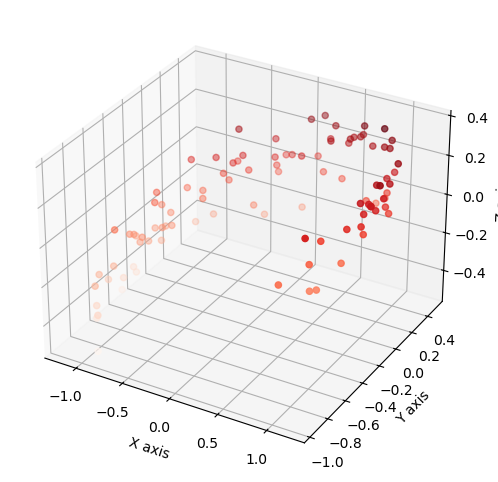

In [8]:
# use the function above to generate data points
#  --actual code line     X_train = generate_data(100)
#  --actual code line   X_train = X_train - X_train.mean(axis=0, keepdims=0)

# preview the data
#  --actual code line ax = plt.axes(projection='3d')
#  --actual code line ax.scatter3D(X_train[:, 0], X_train[:, 1], X_train[:, 2], cmap='Red');


# my code 
# use the function above to generate data points
X_train = generate_data(100)
X_train = X_train - X_train.mean(axis=0, keepdims=True) # Changed keepdims=0 to True for robust broadcasting

# preview the data
plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')

# Fixed line: added c=X_train[:, 2] to provide the data for colormapping
ax.scatter3D(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=X_train[:, 2], cmap='Reds')

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

## Build the Model

Now you will build the simple encoder-decoder model. Notice the number of neurons in each Dense layer. The model will contract in the encoder then expand in the decoder.

In [10]:
#encoder = keras.models.Sequential([keras.layers.Dense(2, input_shape=[3])])
#decoder = keras.models.Sequential([keras.layers.Dense(3, input_shape=[2])])

#autoencoder = keras.models.Sequential([encoder, decoder])



# abive are actual code lines 
# below is my code line 
import keras
from keras import layers

# Define the Encoder
encoder = keras.models.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(2)
])

# Define the Decoder
decoder = keras.models.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(3)
])

# Combine into the Autoencoder
autoencoder = keras.models.Sequential([encoder, decoder])

# Optional: Print summary to verify the "contraction" and "expansion"
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)            │ (None, 2)                   │               8 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_4 (Sequential)            │ (None, 3)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

You can then setup the model for training.

In [11]:
autoencoder.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=0.1))


## Train the Model

You will configure the training to also use the input data as your target output. In our example, that will be `X_train`.

In [12]:
history = autoencoder.fit(X_train, X_train, epochs=200)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1284
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0953
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0710
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0555
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0429 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0351
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0292
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0250
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0218
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0190
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0166
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0150
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0138
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0128
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0118
Epoch 16/200
4/4 ━

## Plot the encoder output

As mentioned, you can use the encoder to compress the input to two dimensions.

In [13]:
# encode the data
codings = encoder.predict(X_train)

# see a sample input-encoder output pair
print(f'input point: {X_train[0]}')
print(f'encoded point: {codings[0]}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
input point: [-0.82980855  0.06027904 -0.23797047]
encoded point: [ 0.5785633  -0.33673254]


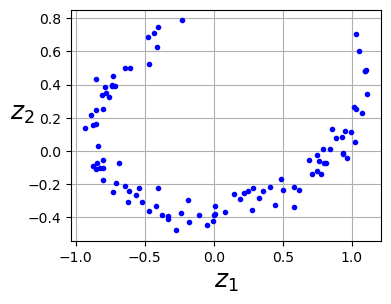

In [14]:
# plot all encoder outputs
fig = plt.figure(figsize=(4,3))
plt.plot(codings[:,0], codings[:, 1], "b.")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid(True)
plt.show()

## Plot the Decoder output

The decoder then tries to reconstruct the original input. See the outputs below. You will see that although not perfect, it still follows the general shape of the original input.

In [15]:
# decode the encoder output
decodings = decoder.predict(codings)

# see a sample output for a single point
print(f'input point: {X_train[0]}')
print(f'encoded point: {codings[0]}')
print(f'decoded point: {decodings[0]}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
input point: [-0.82980855  0.06027904 -0.23797047]
encoded point: [ 0.5785633  -0.33673254]
decoded point: [-0.855619    0.09208865 -0.07756331]


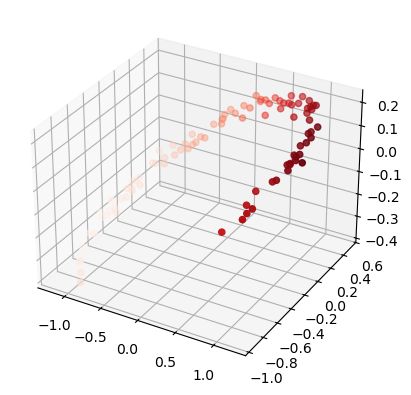

In [16]:
# plot the decoder output
ax = plt.axes(projection='3d')
ax.scatter3D(decodings[:, 0], decodings[:, 1], decodings[:, 2], c=decodings[:, 0], cmap='Reds');

That's it for this simple demonstration of the autoencoder!